# Prueba Proceso General

In [1]:
#Import libraries
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import argrelextrema
from scipy.interpolate import CubicSpline

#Funciones auxiliares
def leer_archivo_txt(nombre_archivo, saltar_lineas=5, delimitador=';'):
    try:
        df = pd.read_csv(nombre_archivo, delimiter=delimitador, skiprows=saltar_lineas)
        df.columns = df.columns.str.strip()
        df['Wave'] = pd.to_numeric(df['Wave'], errors='coerce')
        df['Sample'] = pd.to_numeric(df['Sample'], errors='coerce')
        df.dropna(inplace=True)

        espectro = df['Sample'].values
        wavelength = df['Wave'].values
        return espectro[16:-16], wavelength[16:-16]
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return None

In [17]:
#Leer archivos
# Ruta relativa desde Pre_Processing a los espectros
ruta_espectros = os.path.join('..', 'Spectra', '2.E2E_olivine')

UV1 = os.path.join(ruta_espectros, 'Olivine_LIBS_shot01_7324767SP.txt')
UV2 = os.path.join(ruta_espectros, 'Olivine_LIBS_shot01_7324768SP.txt')
VIS = os.path.join(ruta_espectros, 'Olivine_LIBS_shot01_7324769SP.txt')
NIR = os.path.join(ruta_espectros, 'Olivine_LIBS_shot01_7324770SP.txt')

espectro_UV1, wavelength_UV1 = leer_archivo_txt(UV1)
espectro_UV2, wavelength_UV2 = leer_archivo_txt(UV2)
espectro_VIS, wavelength_VIS = leer_archivo_txt(VIS)
espectro_NIR, wavelength_NIR  = leer_archivo_txt(NIR)


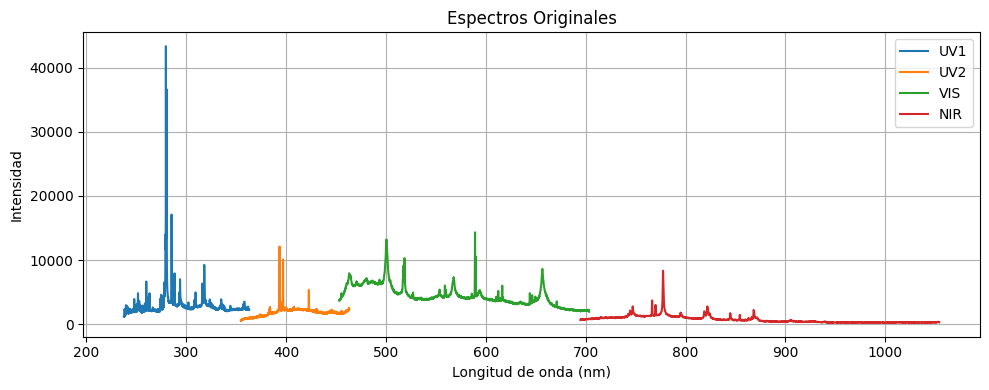

In [18]:
nombres = ['UV1', 'UV2', 'VIS', 'NIR']
espectros = [espectro_UV1, espectro_UV2, espectro_VIS, espectro_NIR]
wavelengths = [wavelength_UV1, wavelength_UV2, wavelength_VIS, wavelength_NIR]

# Visualización
plt.figure(figsize=(10, 4))

# Gráfica 1: Normalización por suma
for i in range(4):
    plt.plot(wavelengths[i], espectros[i], label=f'{nombres[i]}')
plt.title("Espectros Originales")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Intensidad")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import importlib
import preprocess_spectra
importlib.reload(preprocess_spectra)

import preprocess_spectra

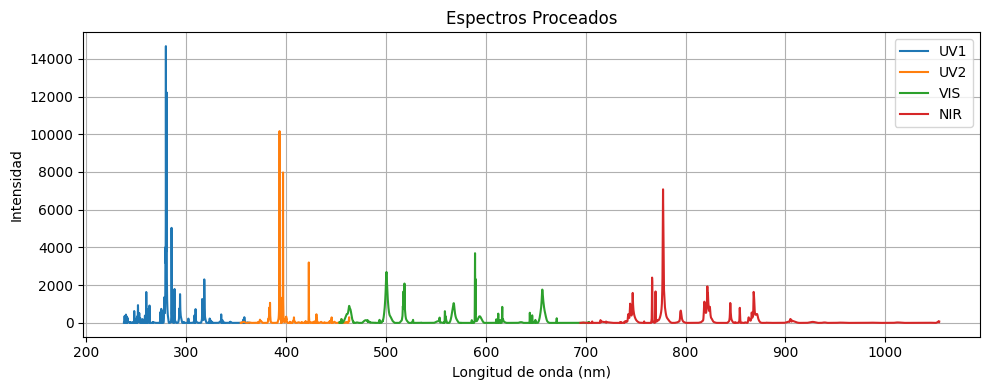

In [24]:
# Preprocesar espectros
espectros_processed =  apply_preprocessing(espectros, wavelengths)

# Visualización
plt.figure(figsize=(10, 4))

# Gráfica 
for i in range(4):
    plt.plot(wavelengths[i], espectros_processed[i], label=f'{nombres[i]}')
plt.title("Espectros Proceados")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Intensidad")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Función de lectura de datos completa

In [3]:
import os
import pandas as pd
import numpy as np

def leer_archivo_txt(nombre_archivo, saltar_lineas=5, delimitador=';'):
    try:
        df = pd.read_csv(nombre_archivo, delimiter=delimitador, skiprows=saltar_lineas)
        df.columns = df.columns.str.strip()
        df['Wave'] = pd.to_numeric(df['Wave'], errors='coerce')
        df['Sample'] = pd.to_numeric(df['Sample'], errors='coerce')
        df.dropna(inplace=True)

        espectro = df['Sample'].values
        wavelength = df['Wave'].values
        return espectro, wavelength
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return None, None

def cargar_espectros(carpeta, nombre_base, quitar_extremos=True):
    """
    Carga automáticamente los archivos UV1, UV2, VIS y NIR relacionados con un mismo experimento.

    Parámetros:
    -----------
    carpeta : str
        Nombre de la subcarpeta dentro de '../Spectra/'.
    nombre_base : str
        Parte común del nombre del archivo sin el sufijo numérico.
    quitar_extremos : bool, opcional
        Si True, elimina los primeros y últimos 16 valores (por defecto True).

    Devuelve:
    ---------
    espectros : list of np.ndarray
        Lista de espectros UV1, UV2, VIS, NIR.
    wavelengths : list of np.ndarray
        Lista de longitudes de onda correspondientes.
    nombres : list of str
        Lista de nombres de los espectros (UV1, UV2, VIS, NIR).
    """
    
    codigos = ['7324767SP', '7324768SP', '7324769SP', '7324770SP']
    nombres = ['UV1', 'UV2', 'VIS', 'NIR']
    espectros = []
    wavelengths = []

    for codigo in codigos:
        ruta = os.path.join('..', 'Spectra', carpeta, f"{nombre_base}_{codigo}.txt")
        espectro, wave = leer_archivo_txt(ruta)

        if espectro is None or wave is None:
            print(f"No se pudo cargar el archivo: {ruta}")
            espectros.append(None)
            wavelengths.append(None)
            continue

        if quitar_extremos:
            espectro = espectro[16:-16]
            wave = wave[16:-16]

        espectros.append(espectro)
        wavelengths.append(wave)

    return espectros, wavelengths, nombres


In [3]:
#Probamos la fución de leer archivos
espectros, wavelengths, nombres = cargar_espectros('20250321_First_test', 'Sulfato50_position2_Burst5_n5')

# Visualización
plt.figure(figsize=(10, 4))

# Gráfica 
for i in range(4):
    plt.plot(wavelengths[i], espectros[i], label=f'{nombres[i]}')
plt.title("Espectros Proceados")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Intensidad")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

# Función para hacer Plots

In [4]:
import matplotlib.pyplot as plt

def plot_spectra(wavelengths, espectros, nombres=None, titulo="Espectros", 
                 xlabel="Longitud de onda (nm)", ylabel="Intensidad", figsize=(12, 5)):
    """
    Representa múltiples espectros en una misma gráfica.

    Parámetros:
    -----------
    wavelengths : list of np.ndarray
        Lista de longitudes de onda para cada espectro.
    espectros : list of np.ndarray
        Lista de espectros (intensidades) a representar.
    nombres : list of str, opcional
        Etiquetas para cada espectro. Si no se proporciona, se enumeran como 'Espectro 1', 'Espectro 2', ...
    titulo : str, opcional
        Título de la gráfica.
    xlabel : str, opcional
        Etiqueta del eje X.
    ylabel : str, opcional
        Etiqueta del eje Y.
    figsize : tuple, opcional
        Tamaño de la figura (por defecto (12, 5)).
    """

    if nombres is None:
        nombres = [f"Espectro {i+1}" for i in range(len(espectros))]

    plt.figure(figsize=figsize)

    for i in range(len(espectros)):
        if wavelengths[i] is not None and espectros[i] is not None:
            plt.plot(wavelengths[i], espectros[i], label=nombres[i])
        else:
            print(f"Aviso: El espectro {i} o su longitud de onda es None y no se representará.")

    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


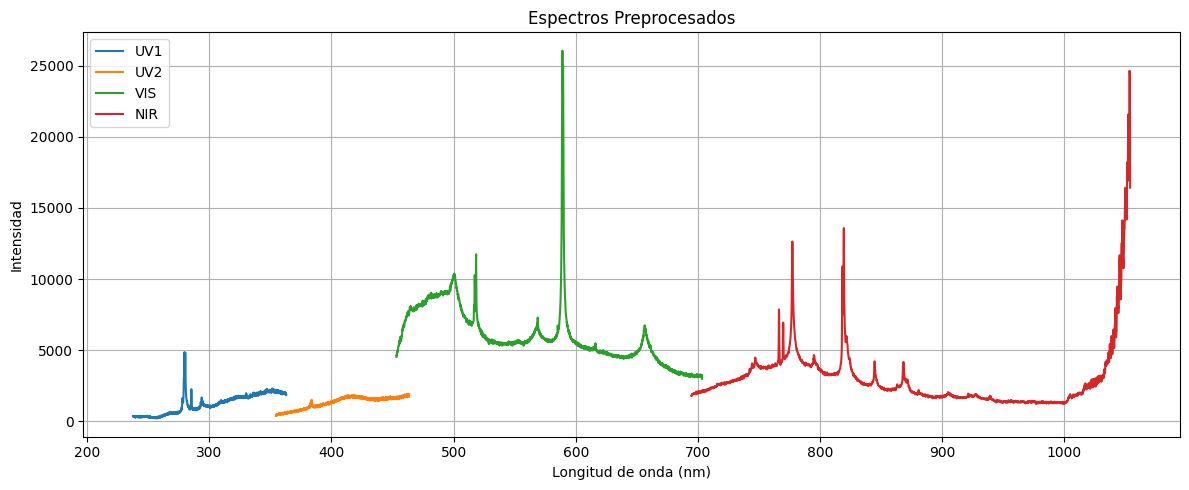

In [15]:
nombres = ['UV1', 'UV2', 'VIS', 'NIR']
plot_spectra(wavelengths, espectros, nombres=nombres, titulo="Espectros Preprocesados")

# Proceso completo

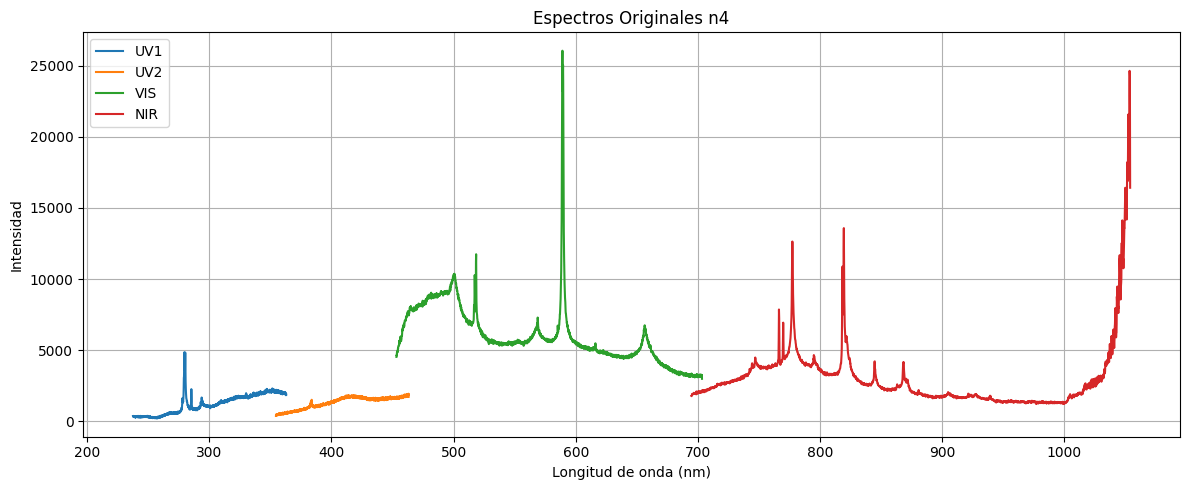

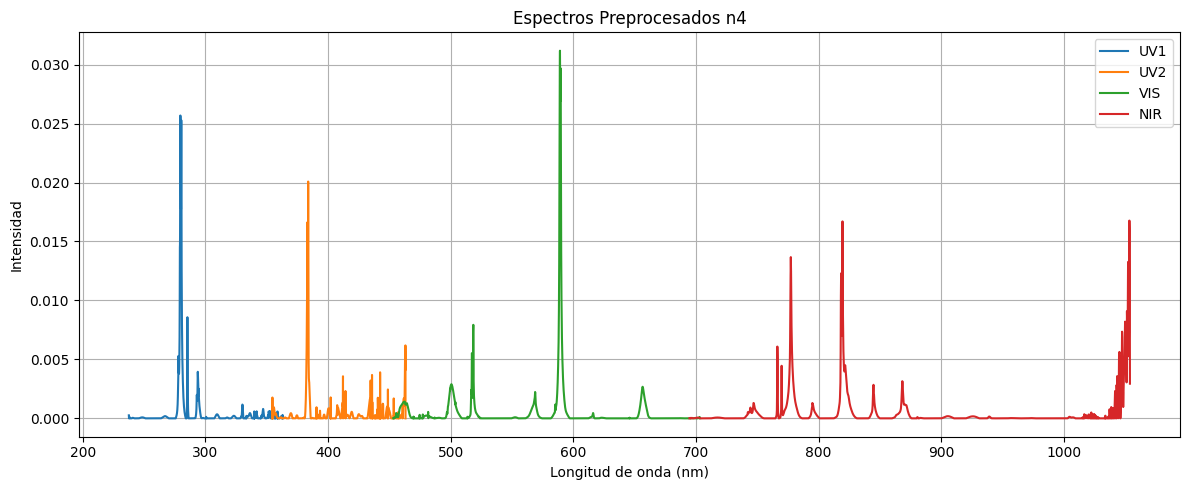

In [47]:
import importlib
import preprocess_spectra
importlib.reload(preprocess_spectra)

from preprocess_spectra import apply_preprocessing

espectros, wavelengths, nombres = cargar_espectros('20250321_First_test', 'Sulfato50_position2_Burst5-n4')
plot_spectra(wavelengths, espectros, nombres=nombres, titulo="Espectros Originales n4")
# Preprocesar espectros
espectros_processed,wavelengths_processed =  apply_preprocessing(espectros, wavelengths, normalization='suma',trim=False)
plot_spectra(wavelengths_processed, espectros_processed, nombres=nombres, titulo="Espectros Preprocesados n4")



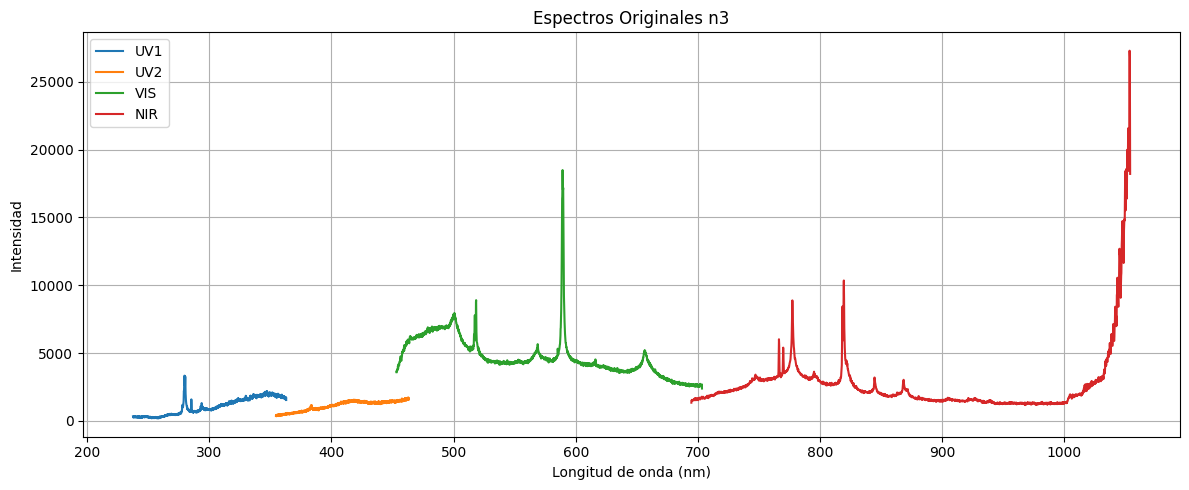

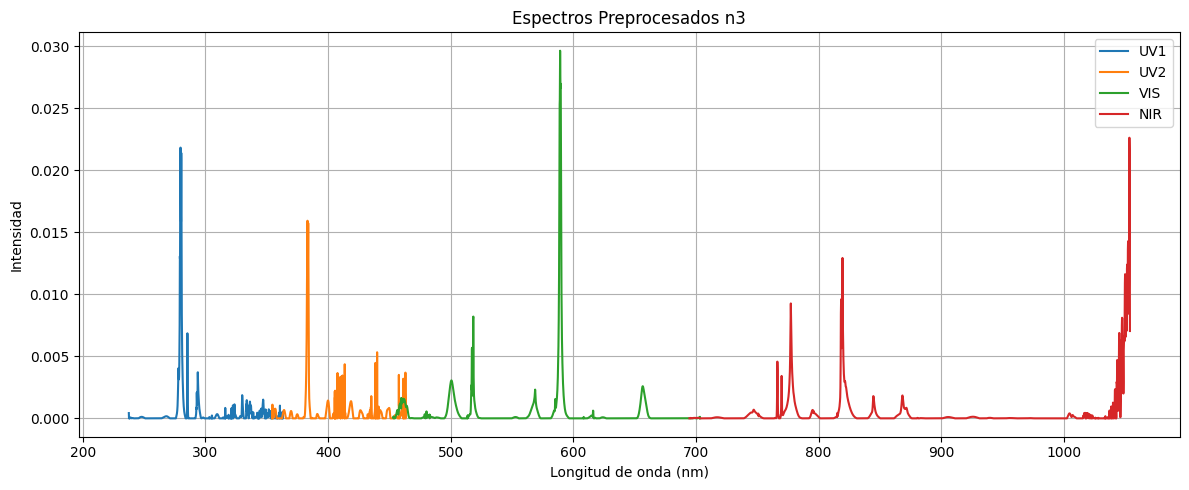

In [50]:
espectros, wavelengths, nombres = cargar_espectros('20250321_First_test', 'Sulfato50_position2_Burst5-n3')
plot_spectra(wavelengths, espectros, nombres=nombres, titulo="Espectros Originales n3")
# Preprocesar espectros
espectros_processed,wavelengths_processed =  apply_preprocessing(espectros, wavelengths, normalization='suma',trim=False)
plot_spectra(wavelengths_processed, espectros_processed, nombres=nombres, titulo="Espectros Preprocesados n3")

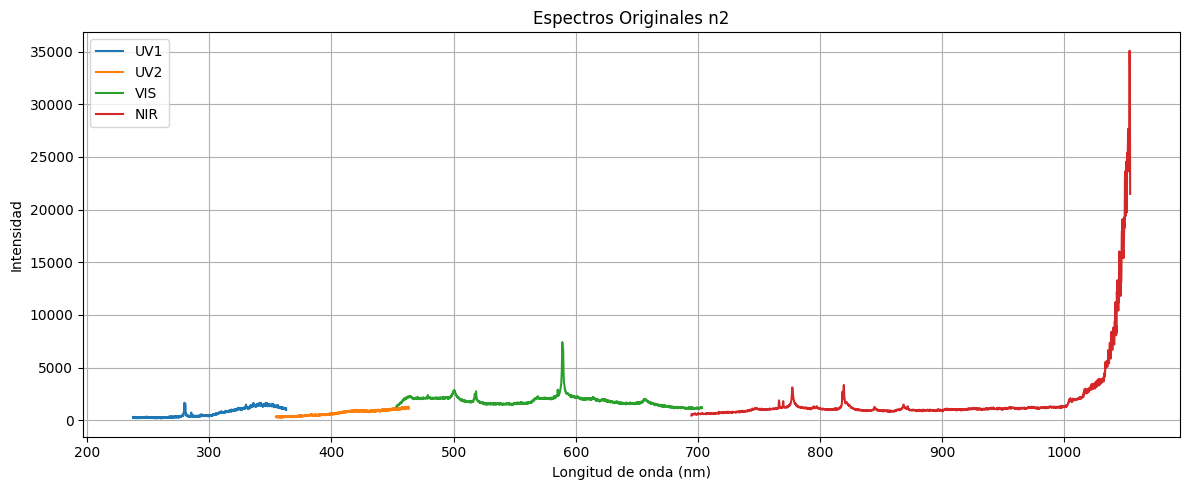

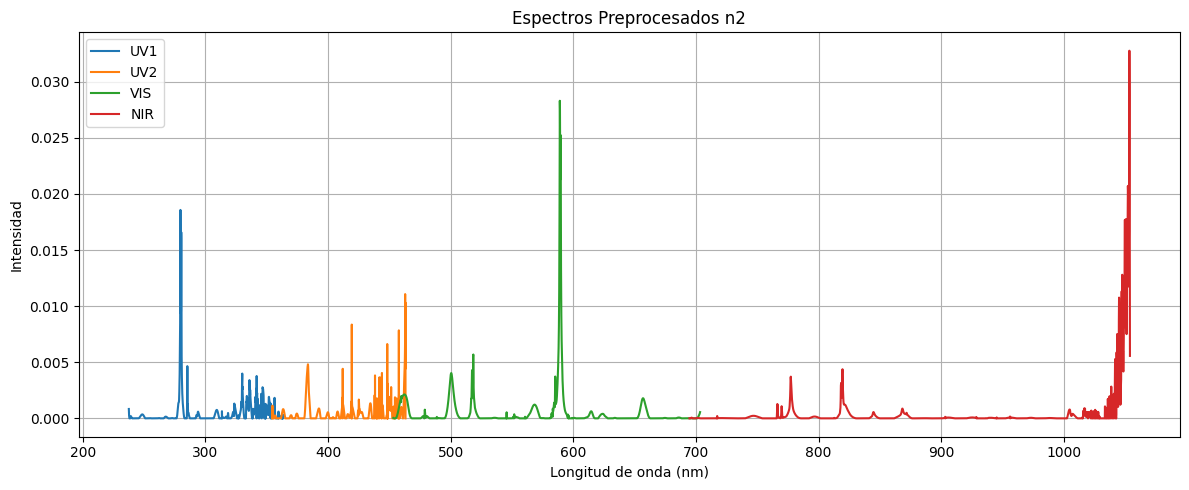

In [48]:
espectros, wavelengths, nombres = cargar_espectros('20250321_First_test', 'Sulfato50_position2_Burst5-n2')
plot_spectra(wavelengths, espectros, nombres=nombres, titulo="Espectros Originales n2")
# Preprocesar espectros
espectros_processed,wavelengths_processed =  apply_preprocessing(espectros, wavelengths, normalization='suma',trim=False)
plot_spectra(wavelengths_processed, espectros_processed, nombres=nombres, titulo="Espectros Preprocesados n2")

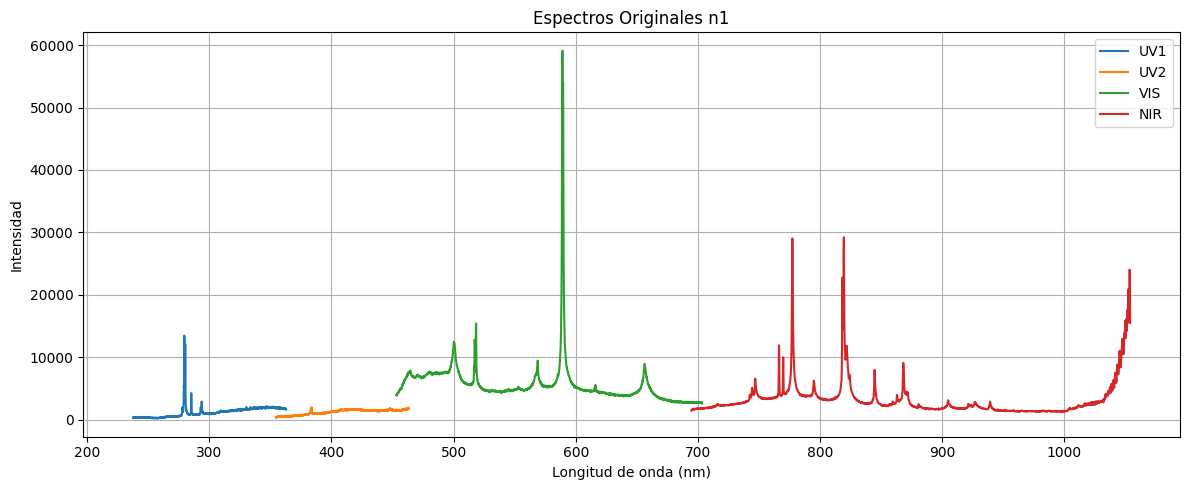

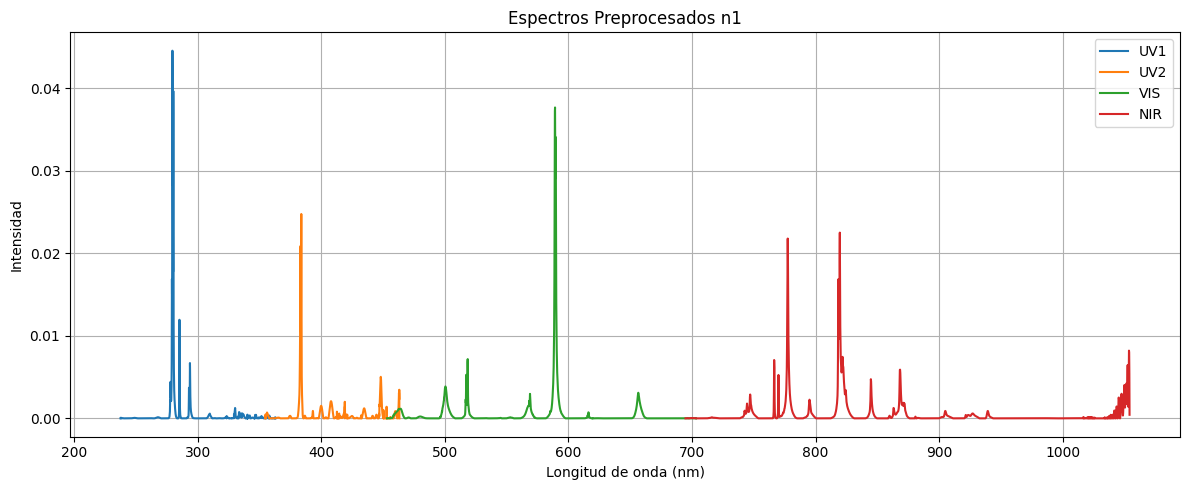

In [51]:
espectros, wavelengths, nombres = cargar_espectros('20250321_First_test', 'Sulfato50_position2_Burst5-n1')
plot_spectra(wavelengths, espectros, nombres=nombres, titulo="Espectros Originales n1")
# Preprocesar espectros
espectros_processed,wavelengths_processed =  apply_preprocessing(espectros, wavelengths, normalization='suma',trim=False)
plot_spectra(wavelengths_processed, espectros_processed, nombres=nombres, titulo="Espectros Preprocesados n1")